# 🏨 ICOICT 2026 – Travlr Data Challenge
## Hotel Recommendation System Based on Popularity, Rating, and Price Analysis

**Nama:** Joyce Stephanie Naibaho
**Institusi:** IT DEL
**Tanggal:** 17 Mei 2026

---
### Deskripsi
Notebook ini berisi:
1. Load dan eksplorasi 3 dataset Travlr (EDA)
2. Preprocessing dan pembersihan data
3. Composite Scoring Model untuk rekomendasi hotel
4. Visualisasi hasil
5. Insight dan kesimpulan

## 📦 0. Install Library yang Dibutuhkan

In [3]:
# Jalankan cell ini sekali saja jika library belum terinstall
# !pip install pandas numpy matplotlib seaborn openpyxl

## 📂 1. Load Dataset

In [6]:
from google.colab import files
uploaded = files.upload()  # pilih 1000_dataset.xlsx di sini

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 20)

FILE_PATH = '1000 dataset (2).xlsx'

df_meta = pd.read_excel(FILE_PATH, sheet_name='accommodation metadata dataset')
df_act  = pd.read_excel(FILE_PATH, sheet_name='Activity Dataset')
df_tx   = pd.read_excel(FILE_PATH, sheet_name='accomodation transaction datase')

print(f'Metadata : {df_meta.shape[0]} baris, {df_meta.shape[1]} kolom')
print(f'Aktivitas: {df_act.shape[0]} baris, {df_act.shape[1]} kolom')
print(f'Transaksi: {df_tx.shape[0]} baris, {df_tx.shape[1]} kolom')

Saving 1000 dataset.xlsx to 1000 dataset (3).xlsx
Metadata : 999 baris, 31 kolom
Aktivitas: 1000 baris, 31 kolom
Transaksi: 999 baris, 4 kolom


## 🔍 2. Eksplorasi Data Awal (EDA)

In [7]:
# ── Tampilkan 5 baris pertama setiap dataset ──
print('=== METADATA AKOMODASI ===')
display(df_meta[['id','name','country','city','category','star_rating',
                  'guest_rating_score','popularity_score','price_in_aud']].head())

print('\n=== TRANSAKSI AKOMODASI ===')
display(df_tx.head())

print('\n=== AKTIVITAS WISATA ===')
display(df_act[['name','categories_as_string','destination_country',
                 'price_in_aud','rating','duration_hours']].head())

=== METADATA AKOMODASI ===


,id,name,country,city,category,star_rating,guest_rating_score,popularity_score,price_in_aud
0,Expedia-5434493,harry’s home Wien hotel & apartments,Austria,Vienna,Hotel,3.5,9000000000000000,1019758.0,172.03
1,Expedia-5429956,Residence San Leo Appartamenti,Italy,Briatico,Apartment,NaN,9000000000000000,1017033.0,0.00
2,Expedia-5430225,Sufubi Gallery Hotel,China,Beihai,Hotel,3.0,1,2.0,0.00
3,Expedia-5430985,Caro Parc,Romania,Bucharest,Hotel,3.0,1,2.0,0.00
4,Expedia-5429267,Shenzhen Castle Hotel,China,Shenzhen,Hotel,4.5,94,101913.0,245.51



=== TRANSAKSI AKOMODASI ===


,payment_date,Property Id,Product,Number Transactions
0,2026-01-03,Agoda-1147045,Quality Hotel Bayside Geelong,1
1,2026-01-03,Agoda-181957,Kalbarri Seafront Villas,1
2,2026-01-03,Agoda-237903,Parkdale Motor Inn,1
3,2026-01-03,Agoda-238026,Mollymook Paradise Haven Motel,1
4,2026-01-03,Agoda-2401162,Knightsbridge Canberra,2



=== AKTIVITAS WISATA ===


,name,categories_as_string,destination_country,price_in_aud,rating,duration_hours
0,Private Horseback Riding,Outdoor Activities,Portugal,311.82,0.0,2.0
1,Private Bachelorette Party with Hors...,Outdoor Activities,Portugal,358.59,0.0,2.0
2,Group transfer with ticket 6km Hikin...,"Tour And Sight Seeing, Cultural",China,64.39,43333335.0,9.0
3,Port Pick Up: Tangier All-inclusive ...,"Tour And Sight Seeing, Cruises & Sai...",Morocco,208.45,4.0,6.0
4,Charming Sunset and Night Tour on a ...,"After Dark, Tour And Sight Seeing, C...",Portugal,259.85,5.0,2.0


In [8]:
# ── Cek missing values ──
print('=== MISSING VALUES – Metadata Akomodasi ===')
missing_meta = df_meta.isnull().sum()
display(missing_meta[missing_meta > 0].sort_values(ascending=False))

print('\n=== MISSING VALUES – Transaksi ===')
print(df_tx.isnull().sum())

print('\n=== MISSING VALUES – Aktivitas ===')
missing_act = df_act.isnull().sum()
display(missing_act[missing_act > 0].sort_values(ascending=False))

=== MISSING VALUES – Metadata Akomodasi ===


,0
tags,999
guest_rating_count,279
guest_rating,279
star_rating_as_string,137
star_rating,123
images,20
destination_country,1



=== MISSING VALUES – Transaksi ===
payment_date           0
Property Id            0
Product                0
Number Transactions    0
dtype: int64

=== MISSING VALUES – Aktivitas ===


,0
tags,1000
has_listing_id_in_bali_db,995
categories_as_string,163
categories,163
currency,8
providers,1
rating,1
provider_activity_codes,1
provider_activity_ids,1
normalized_rating,1


In [9]:
# ── Statistik deskriptif metadata ──
print('=== STATISTIK DESKRIPTIF – Metadata Akomodasi ===')
display(df_meta[['star_rating','guest_rating_score','popularity_score','price_in_aud']].describe())

=== STATISTIK DESKRIPTIF – Metadata Akomodasi ===


,star_rating,guest_rating_score,popularity_score,price_in_aud
count,876.000000,9.990000e+02,9.990000e+02,999.000000
mean,3.187215,1.401401e+15,1.621327e+15,82.329990
std,0.945242,3.178667e+15,3.728458e+15,170.483677
min,0.000000,1.000000e+00,2.000000e+00,0.000000
25%,2.500000,1.000000e+00,1.019530e+05,0.000000
50%,3.000000,8.200000e+01,1.018618e+06,0.000000
75%,4.000000,9.400000e+01,1.019620e+06,137.885000
max,5.000000,1.000000e+16,1.019913e+16,2048.950000


## 📊 3. Visualisasi EDA

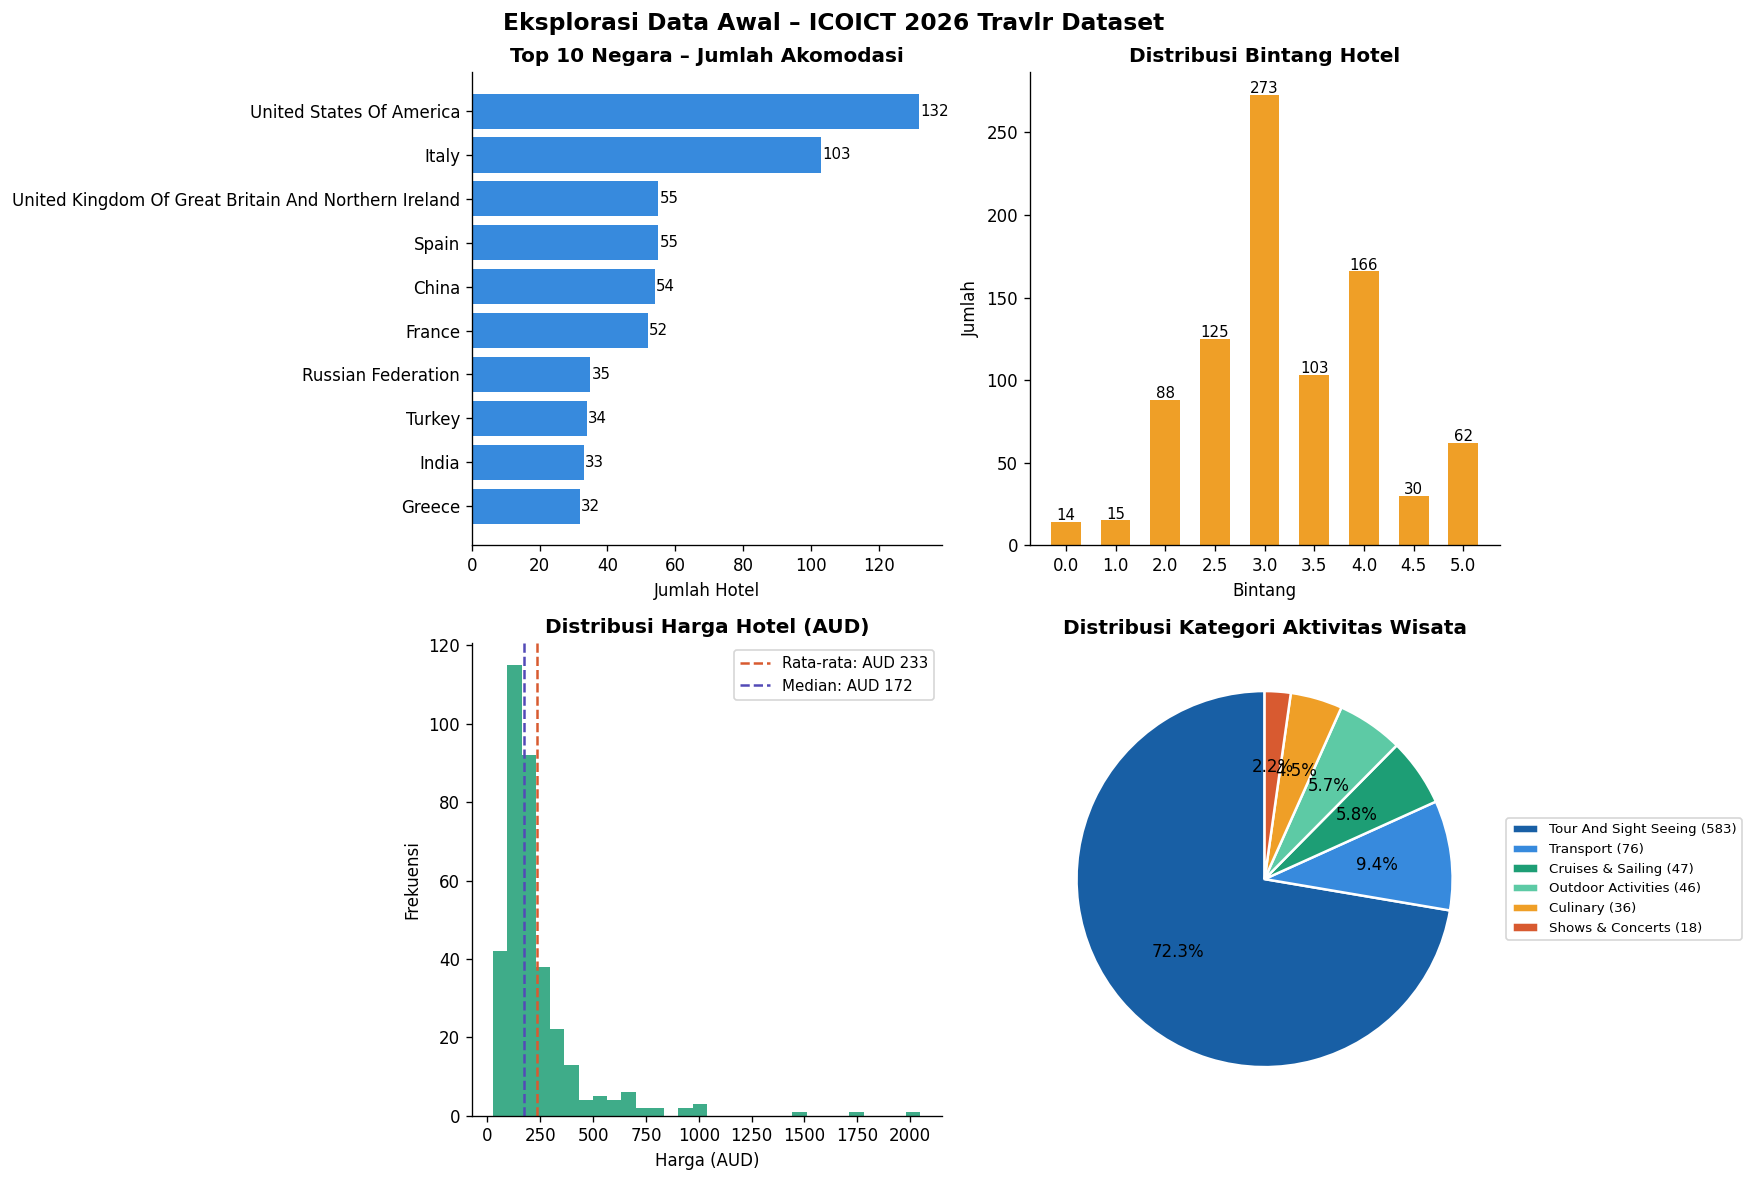

✅ Gambar disimpan: eda_1_overview.png


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Eksplorasi Data Awal – ICOICT 2026 Travlr Dataset',
             fontsize=14, fontweight='bold')

# ── Plot 1: Top 10 Negara ──
top_countries = df_meta['country'].value_counts().head(10)
axes[0,0].barh(top_countries.index[::-1], top_countries.values[::-1],
               color='#378ADD', edgecolor='none')
axes[0,0].set_title('Top 10 Negara – Jumlah Akomodasi', fontweight='bold')
axes[0,0].set_xlabel('Jumlah Hotel')
axes[0,0].spines[['top','right']].set_visible(False)
for i, v in enumerate(top_countries.values[::-1]):
    axes[0,0].text(v+0.3, i, str(v), va='center', fontsize=9)

# ── Plot 2: Distribusi Bintang ──
star_counts = df_meta['star_rating'].dropna().value_counts().sort_index()
axes[0,1].bar(star_counts.index.astype(str), star_counts.values,
              color='#EF9F27', edgecolor='none', width=0.6)
axes[0,1].set_title('Distribusi Bintang Hotel', fontweight='bold')
axes[0,1].set_xlabel('Bintang')
axes[0,1].set_ylabel('Jumlah')
axes[0,1].spines[['top','right']].set_visible(False)
for i, (x, v) in enumerate(zip(star_counts.index.astype(str), star_counts.values)):
    axes[0,1].text(i, v+1, str(v), ha='center', fontsize=9)

# ── Plot 3: Distribusi Harga ──
price_data = df_meta[df_meta['price_in_aud'] > 0]['price_in_aud']
axes[1,0].hist(price_data, bins=30, color='#1D9E75', edgecolor='none', alpha=0.85)
axes[1,0].axvline(price_data.mean(), color='#D85A30', linestyle='--',
                   linewidth=1.5, label=f'Rata-rata: AUD {price_data.mean():.0f}')
axes[1,0].axvline(price_data.median(), color='#534AB7', linestyle='--',
                   linewidth=1.5, label=f'Median: AUD {price_data.median():.0f}')
axes[1,0].set_title('Distribusi Harga Hotel (AUD)', fontweight='bold')
axes[1,0].set_xlabel('Harga (AUD)')
axes[1,0].set_ylabel('Frekuensi')
axes[1,0].legend(fontsize=9)
axes[1,0].spines[['top','right']].set_visible(False)

# ── Plot 4: Kategori Aktivitas ──
cat_counts = df_act['categories_as_string'].dropna().str.split(',').str[0].str.strip().value_counts().head(6)
colors_act = ['#185FA5','#378ADD','#1D9E75','#5DCAA5','#EF9F27','#D85A30']
axes[1,1].pie(cat_counts.values, labels=None, autopct='%1.1f%%',
              colors=colors_act, startangle=90,
              wedgeprops=dict(edgecolor='white', linewidth=1.5))
axes[1,1].set_title('Distribusi Kategori Aktivitas Wisata', fontweight='bold')
axes[1,1].legend([f'{k} ({v})' for k,v in cat_counts.items()],
                  loc='center left', bbox_to_anchor=(1, 0.5), fontsize=8)

plt.tight_layout()
plt.savefig('eda_1_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Gambar disimpan: eda_1_overview.png')

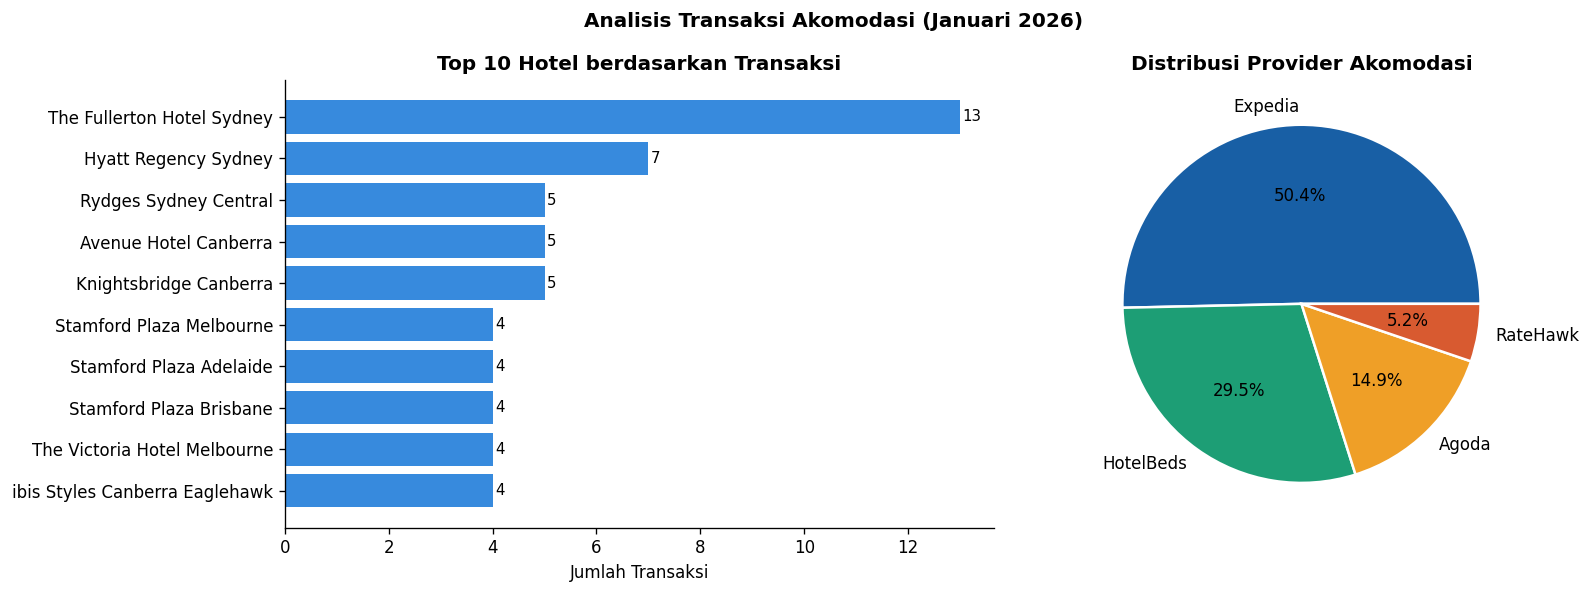

✅ Gambar disimpan: eda_2_transaksi.png


In [11]:
# ── Analisis Transaksi ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Analisis Transaksi Akomodasi (Januari 2026)', fontweight='bold')

# Top 10 Hotel
top_hotels = df_tx.groupby('Product')['Number Transactions'].sum().sort_values(ascending=False).head(10)
axes[0].barh(top_hotels.index[::-1], top_hotels.values[::-1],
             color='#378ADD', edgecolor='none')
axes[0].set_title('Top 10 Hotel berdasarkan Transaksi', fontweight='bold')
axes[0].set_xlabel('Jumlah Transaksi')
axes[0].spines[['top','right']].set_visible(False)
for i, v in enumerate(top_hotels.values[::-1]):
    axes[0].text(v+0.05, i, str(v), va='center', fontsize=9)

# Provider share
provider_share = df_tx['Property Id'].str.split('-').str[0].value_counts()
colors_p = ['#185FA5','#1D9E75','#EF9F27','#D85A30']
axes[1].pie(provider_share.values, labels=provider_share.index,
            autopct='%1.1f%%', colors=colors_p,
            wedgeprops=dict(edgecolor='white', linewidth=1.5))
axes[1].set_title('Distribusi Provider Akomodasi', fontweight='bold')

plt.tight_layout()
plt.savefig('eda_2_transaksi.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Gambar disimpan: eda_2_transaksi.png')

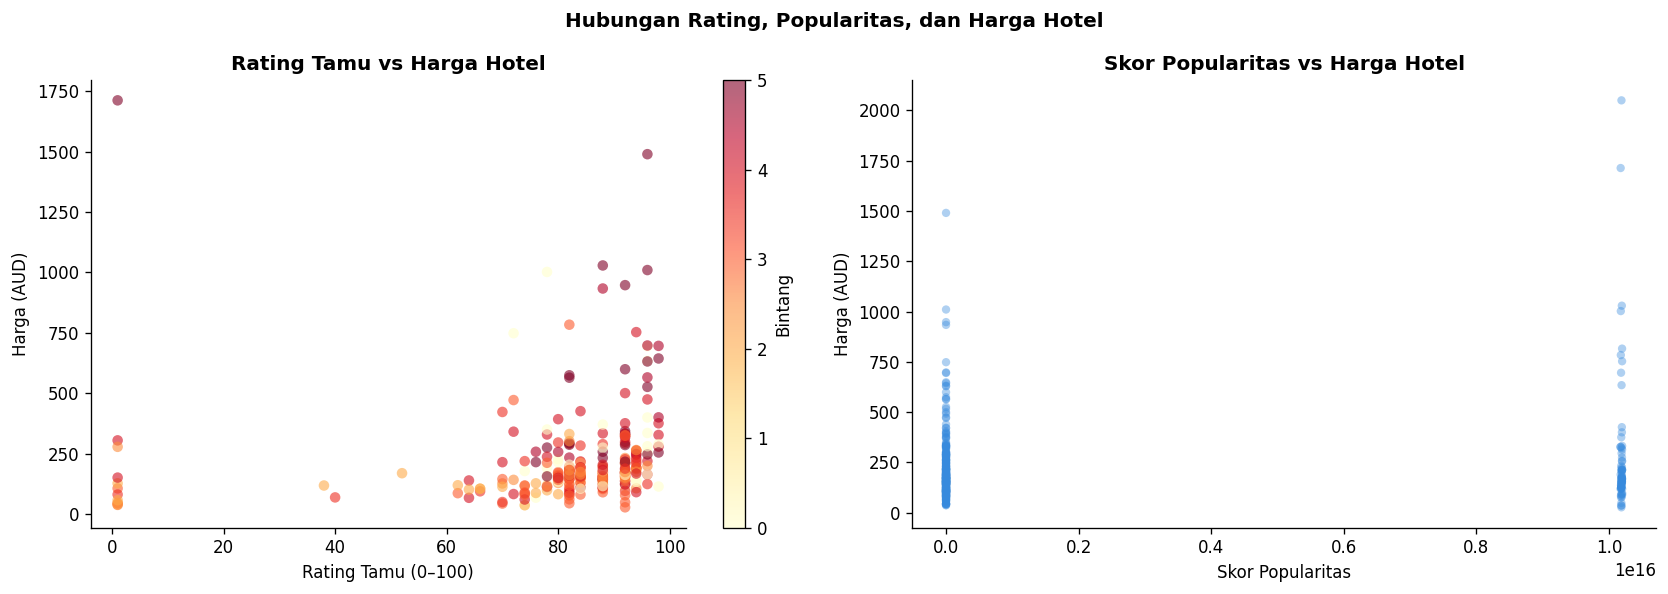

✅ Gambar disimpan: eda_3_korelasi.png


In [12]:
# ── Analisis Korelasi Harga vs Rating & Popularitas ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Hubungan Rating, Popularitas, dan Harga Hotel', fontweight='bold')

# Filter data valid untuk scatter
df_plot = df_meta[
    (df_meta['price_in_aud'] > 0) &
    (df_meta['guest_rating_score'] >= 0) &
    (df_meta['guest_rating_score'] <= 100)
].copy()

sc = axes[0].scatter(
    df_plot['guest_rating_score'],
    df_plot['price_in_aud'],
    c=df_plot['star_rating'].fillna(0),
    cmap='YlOrRd', alpha=0.6, s=40, edgecolors='none'
)
plt.colorbar(sc, ax=axes[0], label='Bintang')
axes[0].set_title('Rating Tamu vs Harga Hotel', fontweight='bold')
axes[0].set_xlabel('Rating Tamu (0–100)')
axes[0].set_ylabel('Harga (AUD)')
axes[0].spines[['top','right']].set_visible(False)

df_pop = df_meta[df_meta['price_in_aud'] > 0].copy()
axes[1].scatter(
    df_pop['popularity_score'], df_pop['price_in_aud'],
    color='#378ADD', alpha=0.4, s=25, edgecolors='none'
)
axes[1].set_title('Skor Popularitas vs Harga Hotel', fontweight='bold')
axes[1].set_xlabel('Skor Popularitas')
axes[1].set_ylabel('Harga (AUD)')
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('eda_3_korelasi.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Gambar disimpan: eda_3_korelasi.png')

## 🧹 4. Preprocessing Data

In [13]:
# ── Preprocessing metadata untuk scoring ──
df = df_meta.copy()

# Konversi tipe data
df['guest_rating_score'] = pd.to_numeric(df['guest_rating_score'], errors='coerce')
df['popularity_score']   = pd.to_numeric(df['popularity_score'],   errors='coerce')
df['price_in_aud']       = pd.to_numeric(df['price_in_aud'],       errors='coerce')
df['star_rating']        = pd.to_numeric(df['star_rating'],        errors='coerce')

# Filter data valid:
# - harga > 0 (bukan gratisan/tidak tersedia)
# - rating dalam rentang wajar 0–100
# - tidak ada nilai kosong pada kolom kunci
df_valid = df[
    (df['price_in_aud'] > 0) &
    (df['guest_rating_score'] >= 0) &
    (df['guest_rating_score'] <= 100)
].dropna(subset=['guest_rating_score', 'popularity_score']).copy()

print(f'Data awal       : {len(df)} baris')
print(f'Data valid      : {len(df_valid)} baris')
print(f'Data dikeluarkan: {len(df) - len(df_valid)} baris (outlier / missing)')
display(df_valid[['name','country','city','star_rating',
                   'price_in_aud','guest_rating_score','popularity_score']].head(5))

Data awal       : 999 baris
Data valid      : 270 baris
Data dikeluarkan: 729 baris (outlier / missing)


,name,country,city,star_rating,price_in_aud,guest_rating_score,popularity_score
4,Shenzhen Castle Hotel,China,Shenzhen,4.5,245.51,94,1.019130e+05
7,InterContinental Bali Sanur Resort b...,Indonesia,Denpasar,5.0,332.47,92,1.019809e+16
18,Divine Resort Laxman Jhula,India,Narendranagar,3.5,422.12,70,1.018547e+06
19,Apartamentos Cabau Cala D'Or,Spain,Mogan,3.0,290.19,82,1.019520e+05
21,Holiday Inn Express Ahmdabad Prahlad...,India,Ahmedabad,4.0,82.19,72,1.019038e+06


## 🏆 5. Composite Scoring Model

Formula:
$$CS = 0.4 \times norm(Popularity) + 0.4 \times norm(GuestRating) + 0.2 \times (1 - norm(Price))$$

- **norm(x)** = normalisasi Min-Max → nilai [0, 1]
- Bobot 0.4 untuk popularitas dan rating (kualitas & kepercayaan)
- Bobot 0.2 untuk keterjangkauan harga (lebih murah = skor lebih tinggi)

In [14]:
# ── Fungsi normalisasi Min-Max ──
def minmax_normalize(series):
    mn, mx = series.min(), series.max()
    if mx == mn:
        return pd.Series([0.5] * len(series), index=series.index)
    return (series - mn) / (mx - mn)

# ── Normalisasi kolom ──
df_valid['norm_popularity'] = minmax_normalize(df_valid['popularity_score'])
df_valid['norm_rating']     = minmax_normalize(df_valid['guest_rating_score'])
df_valid['norm_price']      = minmax_normalize(df_valid['price_in_aud'])

# ── Hitung Composite Score ──
W_POPULARITY = 0.4
W_RATING     = 0.4
W_PRICE      = 0.2

df_valid['composite_score'] = (
    W_POPULARITY * df_valid['norm_popularity'] +
    W_RATING     * df_valid['norm_rating'] +
    W_PRICE      * (1 - df_valid['norm_price'])   # 1-norm karena lebih murah = lebih baik
)

print('✅ Composite Score berhasil dihitung!')
print(f'   Range skor: {df_valid["composite_score"].min():.4f} – {df_valid["composite_score"].max():.4f}')
print(f'   Rata-rata : {df_valid["composite_score"].mean():.4f}')

✅ Composite Score berhasil dihitung!
   Range skor: 0.1671 – 0.9796
   Rata-rata : 0.5883


In [15]:
# ── Top 10 Hotel Rekomendasi ──
cols_show = ['name','country','city','star_rating','price_in_aud',
             'guest_rating_score','composite_score']

top10 = df_valid.nlargest(10, 'composite_score')[cols_show].reset_index(drop=True)
top10.index += 1
top10.columns = ['Nama Hotel','Negara','Kota','Bintang','Harga (AUD)','Rating (0-100)','CS Score']
top10['CS Score'] = top10['CS Score'].round(4)

print('🏆 TOP 10 HOTEL BERDASARKAN COMPOSITE SCORE:')
display(top10)

🏆 TOP 10 HOTEL BERDASARKAN COMPOSITE SCORE:


,Nama Hotel,Negara,Kota,Bintang,Harga (AUD),Rating (0-100),CS Score
1,Akla Hotel La Casa Del Puente,Spain,Soba,3.5,123.59,96,0.9796
2,Gold Central Hotel by Haviland,Viet Nam,Da Nang,3.0,27.26,92,0.9748
3,Flamingo Rocks,South Africa,Umhlanga,4.0,121.87,92,0.9634
4,Belfiore Park Hotel - Adults Only,Italy,Brenzone sul Garda,4.0,326.86,98,0.9634
5,Hotel Malika Bukhara,Uzbekistan,Bukhara,4.5,136.35,92,0.9616
6,Holiday Inn Express Suites Van Buren...,United States Of America,Van Buren,2.5,148.86,92,0.9604
7,InterContinental Pyeongchang Resort ...,Korea (Republic Of),Pyeongchang,4.5,168.27,92,0.9584
8,Aristi Mountain Resort and Villas,Greece,Zagori,4.0,375.22,98,0.9582
9,Hotel Salino Port Soller - Adults On...,Spain,Sóller,4.5,399.84,98,0.9556
10,Comfort Suites Flowood - Jackson Air...,United States Of America,Flowood,2.5,209.34,92,0.9532


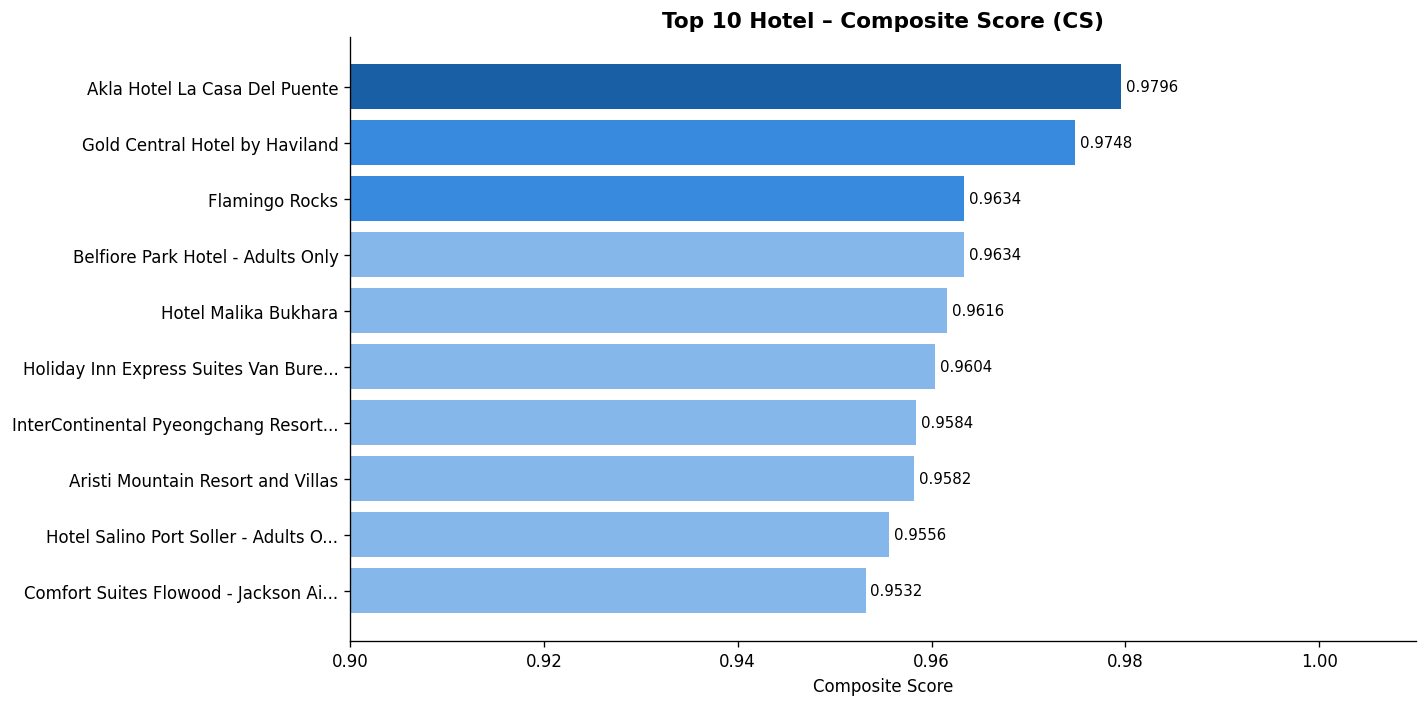

✅ Gambar disimpan: hasil_top10_scoring.png


In [16]:
# ── Visualisasi Top 10 ──
fig, ax = plt.subplots(figsize=(12, 6))

names_short = [n[:35]+'...' if len(n)>35 else n for n in top10['Nama Hotel']]
colors_bar  = ['#185FA5' if i == 0 else '#378ADD' if i < 3 else '#85B7EB'
               for i in range(len(top10))]

bars = ax.barh(names_short[::-1], top10['CS Score'].values[::-1],
               color=colors_bar[::-1], edgecolor='none')
ax.set_title('Top 10 Hotel – Composite Score (CS)', fontweight='bold', fontsize=13)
ax.set_xlabel('Composite Score')
ax.set_xlim(0.9, 1.01)
ax.spines[['top','right']].set_visible(False)

for bar, val in zip(bars, top10['CS Score'].values[::-1]):
    ax.text(val + 0.0005, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('hasil_top10_scoring.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Gambar disimpan: hasil_top10_scoring.png')

## 🔎 6. Fungsi Rekomendasi per Destinasi

In [17]:
def rekomendasikan_hotel(negara=None, kota=None, top_n=5):
    """
    Tampilkan rekomendasi hotel berdasarkan Composite Score.

    Parameter:
    - negara : str, filter berdasarkan negara (opsional)
    - kota   : str, filter berdasarkan kota (opsional)
    - top_n  : int, jumlah rekomendasi yang ditampilkan
    """
    df_filter = df_valid.copy()

    if negara:
        df_filter = df_filter[df_filter['country'].str.lower().str.contains(negara.lower())]
    if kota:
        df_filter = df_filter[df_filter['city'].str.lower().str.contains(kota.lower())]

    if df_filter.empty:
        print(f'❌ Tidak ada data untuk: negara={negara}, kota={kota}')
        return

    result = df_filter.nlargest(top_n, 'composite_score')[
        ['name','country','city','star_rating','price_in_aud',
         'guest_rating_score','composite_score']
    ].reset_index(drop=True)
    result.index += 1
    result.columns = ['Nama Hotel','Negara','Kota','Bintang','Harga (AUD)','Rating','CS Score']
    result['CS Score'] = result['CS Score'].round(4)

    judul = f'Top {top_n} Hotel'
    if negara: judul += f' di {negara}'
    if kota:   judul += f', {kota}'
    print(f'🏨 {judul}:')
    display(result)

# ── Contoh penggunaan ──
rekomendasikan_hotel(negara='Spain', top_n=5)

🏨 Top 5 Hotel di Spain:


,Nama Hotel,Negara,Kota,Bintang,Harga (AUD),Rating,CS Score
1,Akla Hotel La Casa Del Puente,Spain,Soba,3.5,123.59,96,0.9796
2,Hotel Salino Port Soller - Adults On...,Spain,Sóller,4.5,399.84,98,0.9556
3,Holiday Inn Express Madrid-Leganes b...,Spain,Leganes,3.0,155.32,88,0.9434
4,Bordoy Alcudia Port Suites - Adult Only,Spain,Alcúdia,5.0,254.34,98,0.5731
5,Musik Boutique Hotel - Solo Adultos,Spain,Barcelona,3.0,261.06,94,0.5558


In [18]:
# Coba negara lain
rekomendasikan_hotel(negara='Italy', top_n=5)

🏨 Top 5 Hotel di Italy:


,Nama Hotel,Negara,Kota,Bintang,Harga (AUD),Rating,CS Score
1,Belfiore Park Hotel - Adults Only,Italy,Brenzone sul Garda,4.0,326.86,98,0.9634
2,MAISON DEGAS dimora de charme,Italy,Naples,NaN,210.84,84,0.9203
3,B&B Palazzo del Capitolo - By I Bast...,Italy,Gallipoli,NaN,113.43,98,0.5898
4,Luxor Beach Boutique Hotel Cattolica,Italy,Cattolica,4.0,90.01,94,0.5761
5,Quartuccio - Albergo Diffuso,Italy,Gaeta,NaN,164.16,96,0.5755


In [19]:
# Semua negara yang tersedia dalam data valid
print('Negara yang tersedia dalam data valid:')
print(sorted(df_valid['country'].unique()))

Negara yang tersedia dalam data valid:
['Argentina', 'Australia', 'Austria', 'Bahrain', 'Brazil', 'Canada', 'Chile', 'China', 'Colombia', 'Costa Rica', 'Czechia', 'Egypt', 'Ethiopia', 'France', 'Germany', 'Ghana', 'Greece', 'Hungary', 'India', 'Indonesia', 'Israel', 'Italy', 'Japan', 'Kazakhstan', 'Korea (Republic Of)', 'Malaysia', 'Maldives', 'Mauritania', 'Mauritius', 'Mexico', 'Netherlands', 'New Zealand', 'Oman', 'Papua New Guinea', 'Poland', 'Portugal', 'Saudi Arabia', 'Senegal', 'South Africa', 'Spain', 'Switzerland', 'Tanzania, United Republic Of', 'Thailand', 'Tunisia', 'Turkey', 'United Arab Emirates', 'United Kingdom Of Great Britain And Northern Ireland', 'United States Of America', 'Uzbekistan', 'Viet Nam']


## 📈 7. Analisis Tambahan – Distribusi CS Score per Segmen Bintang

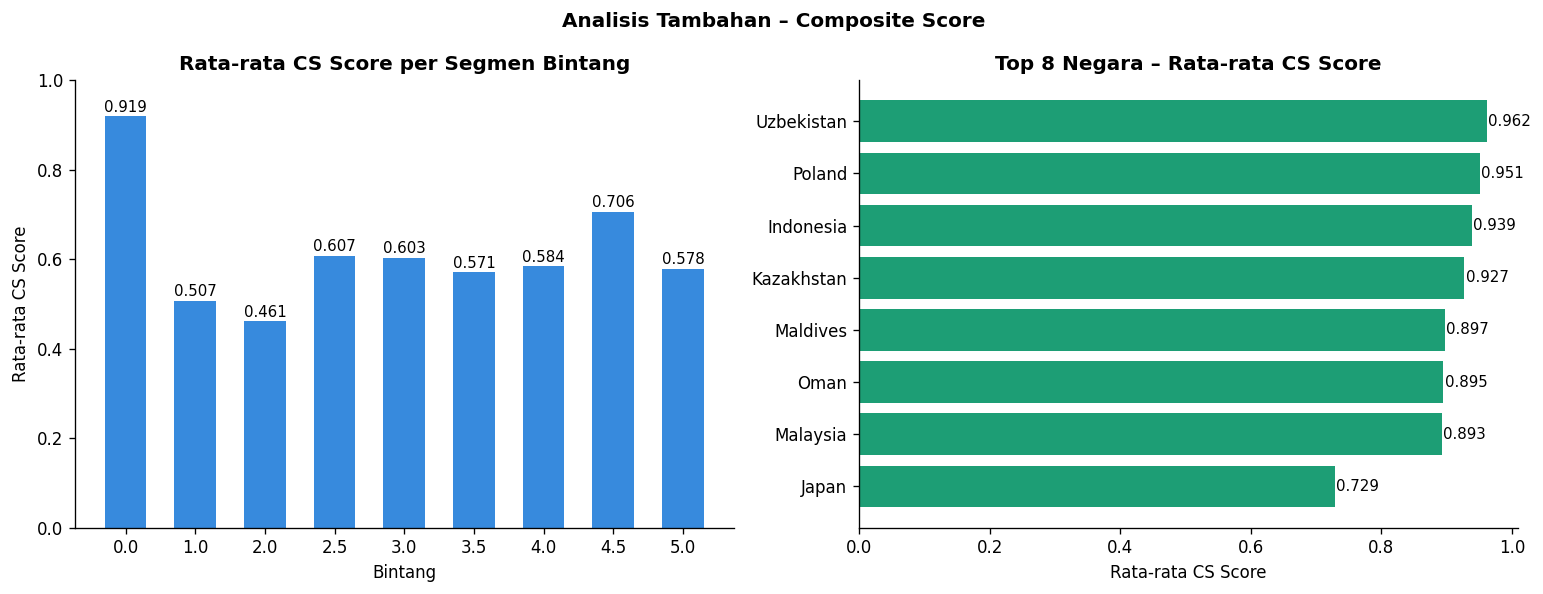

✅ Gambar disimpan: analisis_tambahan.png


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Analisis Tambahan – Composite Score', fontweight='bold')

# ── CS Score per segmen bintang ──
df_star = df_valid.dropna(subset=['star_rating'])
star_groups = df_star.groupby('star_rating')['composite_score'].mean().sort_index()
axes[0].bar(star_groups.index.astype(str), star_groups.values,
            color='#378ADD', edgecolor='none', width=0.6)
axes[0].set_title('Rata-rata CS Score per Segmen Bintang', fontweight='bold')
axes[0].set_xlabel('Bintang')
axes[0].set_ylabel('Rata-rata CS Score')
axes[0].set_ylim(0, 1)
axes[0].spines[['top','right']].set_visible(False)
for i, (x, v) in enumerate(zip(star_groups.index.astype(str), star_groups.values)):
    axes[0].text(i, v+0.01, f'{v:.3f}', ha='center', fontsize=9)

# ── CS Score per top 5 negara ──
top5_neg = df_valid.groupby('country')['composite_score'].mean().nlargest(8)
axes[1].barh(top5_neg.index[::-1], top5_neg.values[::-1],
             color='#1D9E75', edgecolor='none')
axes[1].set_title('Top 8 Negara – Rata-rata CS Score', fontweight='bold')
axes[1].set_xlabel('Rata-rata CS Score')
axes[1].spines[['top','right']].set_visible(False)
for bar, val in zip(axes[1].patches, top5_neg.values[::-1]):
    axes[1].text(val+0.002, bar.get_y()+bar.get_height()/2,
                 f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('analisis_tambahan.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Gambar disimpan: analisis_tambahan.png')

## 💡 8. Insight dan Kesimpulan

In [21]:
print('='*60)
print('📊 RINGKASAN INSIGHT UTAMA')
print('='*60)

print(f"""
1. DATASET
   - Metadata  : {len(df_meta)} hotel dari {df_meta['country'].nunique()} negara
   - Transaksi : {len(df_tx)} transaksi, {df_tx['Product'].nunique()} hotel unik
   - Aktivitas : {len(df_act)} aktivitas wisata
   - Data valid untuk scoring: {len(df_valid)} properti

2. DISTRIBUSI PASAR
   - Negara terbanyak: {df_meta['country'].value_counts().index[0]} ({df_meta['country'].value_counts().iloc[0]} properti)
   - Segmen dominan: Hotel bintang 3 ({df_meta['star_rating'].value_counts().get(3.0, 0)} properti)
   - Rata-rata harga: AUD {df_meta[df_meta['price_in_aud']>0]['price_in_aud'].mean():.2f}

3. TRANSAKSI
   - Hotel terlaris: {df_tx.groupby('Product')['Number Transactions'].sum().idxmax()}
     ({df_tx.groupby('Product')['Number Transactions'].sum().max()} transaksi dalam 3 hari)
   - Provider terbesar: {df_tx['Property Id'].str.split('-').str[0].value_counts().index[0]}

4. COMPOSITE SCORING
   - Hotel terbaik: {df_valid.nlargest(1,'composite_score')['name'].values[0]}
   - CS Score tertinggi: {df_valid['composite_score'].max():.4f}
   - Temuan utama: Harga tinggi TIDAK menjamin rating tinggi.
     Hotel berkualitas dapat ditemukan di berbagai rentang harga.
""")
print('='*60)

📊 RINGKASAN INSIGHT UTAMA

1. DATASET
   - Metadata  : 999 hotel dari 88 negara
   - Transaksi : 999 transaksi, 894 hotel unik
   - Aktivitas : 1000 aktivitas wisata
   - Data valid untuk scoring: 270 properti

2. DISTRIBUSI PASAR
   - Negara terbanyak: United States Of America (132 properti)
   - Segmen dominan: Hotel bintang 3 (273 properti)
   - Rata-rata harga: AUD 233.00

3. TRANSAKSI
   - Hotel terlaris: The Fullerton Hotel Sydney
     (13 transaksi dalam 3 hari)
   - Provider terbesar: Expedia

4. COMPOSITE SCORING
   - Hotel terbaik: Akla Hotel La Casa Del Puente
   - CS Score tertinggi: 0.9796
   - Temuan utama: Harga tinggi TIDAK menjamin rating tinggi.
     Hotel berkualitas dapat ditemukan di berbagai rentang harga.

